## WEEK-04-VISUALISATION AND DASHBOARD

The objective of this project is to convert the cleaned dataset into a set of visual stories to better understand the data, extract meaningful insights, and support decision-making. Visualizations make it easier to analyze data and make informed decisions. Tools such as Power BI and Streamlit are used to create charts, dashboards, and other visualizations that help present these insights effectively.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

df = pd.read_csv("cleaned_netflixx.csv")

df.head()

#df.shape

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2.0,Seasons


## 1. COMFIRM WE ARE BUILDING ON CLEANED DATASET!

We are going to use assingment 3 pre-processed data.Now we are going to preview that cleanes dataset and check wheather it is clenaed properly or not for our visualization.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Total rows: {df.shape[0]} | Total columns: {df.shape[1]}")

Missing values per column:
show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added        0
month_added       0
duration_value    0
duration_unit     0
dtype: int64

Total rows: 8709 | Total columns: 16


In [6]:
df.duplicated().sum()


np.int64(0)

## VISUALIZATIONS AND CHARTS

Now we are going to add charts based on our dataset and try to understand our dataset based on these charts .

In [7]:
print(df.columns.tolist())

['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'year_added', 'month_added', 'duration_value', 'duration_unit']


## BAR CHART- 
This bar chart counts how many titles fall into each content type — Movie or TV Show — so we can see which format Netflix relies on more.

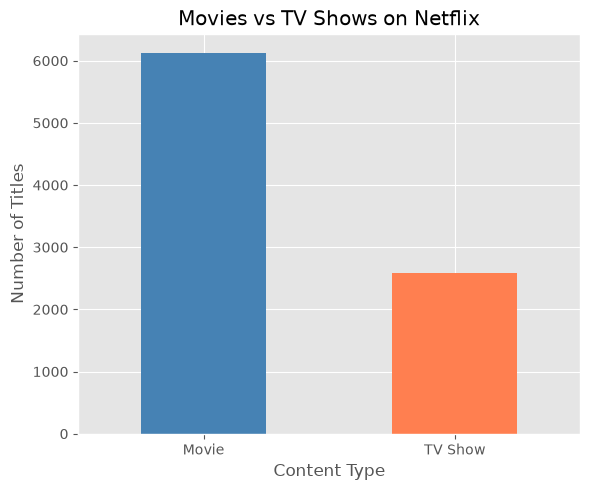

Movies make up 70.4% of the catalog.


In [22]:
plt.figure(figsize=(6, 5))
df["type"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

type_counts = df["type"].value_counts()
movie_pct = round(type_counts["Movie"] / type_counts.sum() * 100, 1)
print(f"Movies make up {movie_pct}% of the catalog.")

## INSIGHT

This chart shows that movies make up about 70% of Netflix's content, making them far more common than TV shows on the platform

## LINE CHART-

This line chart tracks the number of titles added to Netflix each year, helping us see how content additions have changed over time.

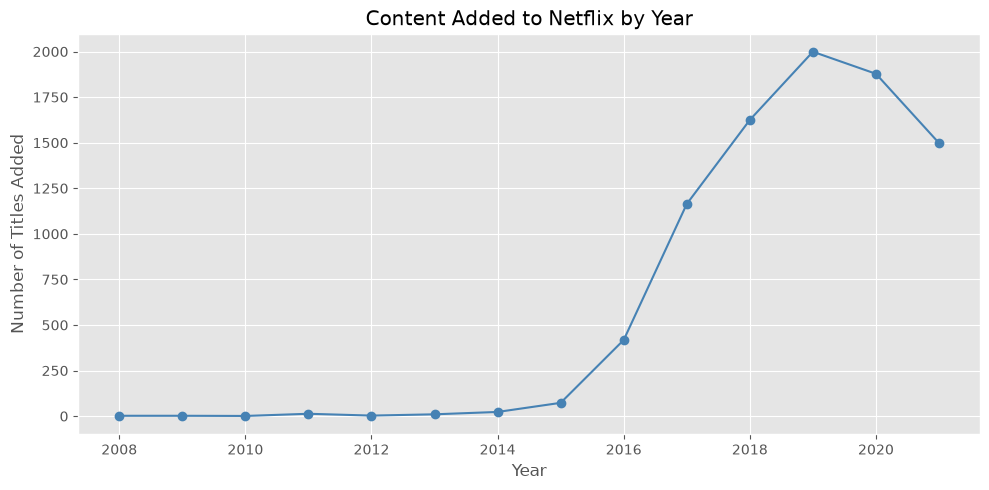

Peak content-addition year: 2019 (1999 titles)


In [23]:
yearly_additions = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
yearly_additions.plot(kind="line", marker="o", color="steelblue")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)
plt.tight_layout()
plt.show()

peak_year = yearly_additions.idxmax()
print(f"Peak content-addition year: {peak_year} ({yearly_additions.max()} titles)")

## INSIGHT
 The chart shows that content additions grew steadily until 2019, which was the peak year with nearly 2,000 titles added, before slightly declining in 2020 and 2021.

## PIE CHART-

This pie chart breaks down the top 6 content ratings by percentage, showing what portion of the catalog each rating makes up.

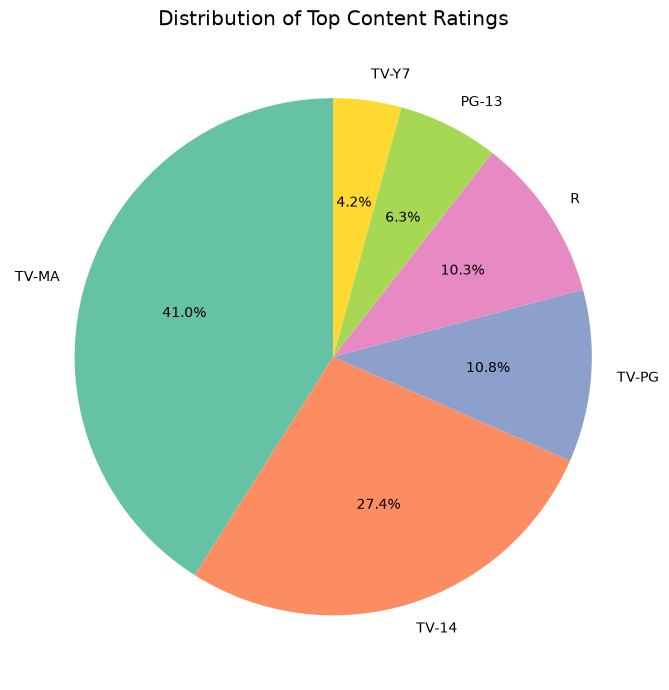

In [11]:
top_ratings = df["rating"].value_counts().head(6)

plt.figure(figsize=(7, 7))
plt.pie(top_ratings, labels=top_ratings.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("Set2"))
plt.title("Distribution of Top Content Ratings")
plt.tight_layout()
plt.show()


## INSIGHT

The chart shows that TV-MA (mature audience) is the most common rating, meaning Netflix's catalog is weighted more toward adult content than family-friendly content.

## HISTOGRAM

This histogram groups titles by release year into bins, showing how many titles fall into each year range and where most of the content is concentrated.

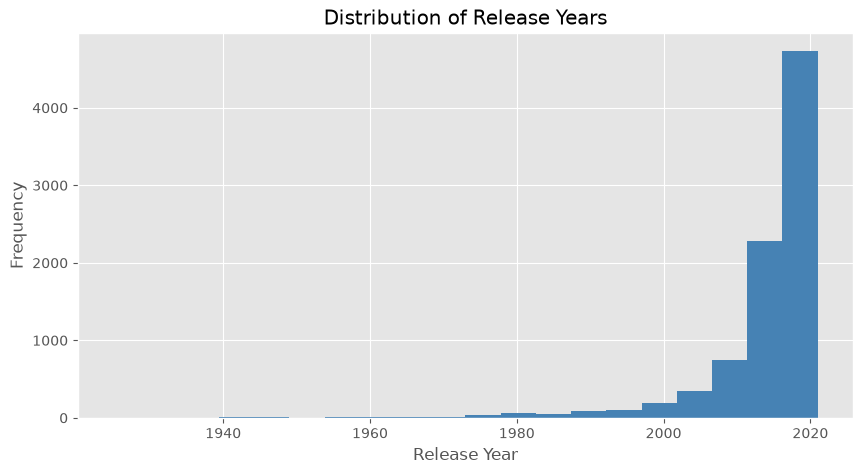

In [13]:
plt.figure(figsize=(10,5))

plt.hist(df["release_year"], bins=20, color="steelblue")

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")

plt.show()

## INSIGHT

The chart shows that most titles were released after 2013, with very few titles older than that, meaning Netflix's catalog is built mainly around recent content rather than classic titles.

## SCATTER PLOT

This scatter plot compares release year against movie duration, with each dot representing one movie, to check whether movie length has changed as newer titles were released.

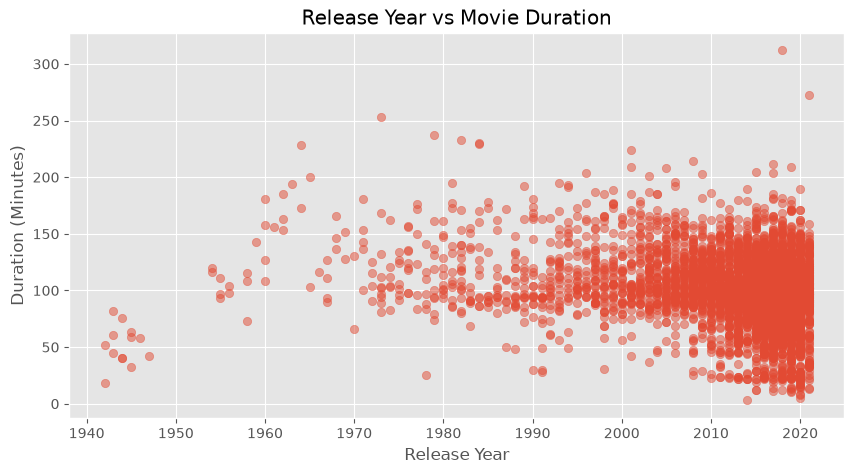

In [14]:
movies = df[df["duration_unit"] == "min"]

plt.figure(figsize=(10,5))

plt.scatter(
    movies["release_year"],
    movies["duration_value"],
    alpha=0.5
)

plt.title("Release Year vs Movie Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (Minutes)")

plt.show()

## INSIGHT

The chart shows a weak downward pattern, meaning newer movies tend to be slightly shorter than older ones, though the relationship is not very strong.

## BOX-PLOT

This box plot compares the spread of duration values between Movies and TV Shows, showing the typical range as well as any unusual outliers.

C:\Users\abeer\AppData\Local\Temp\ipykernel_24408\2891924678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="type", y="duration_value", data=df, palette="Set2")


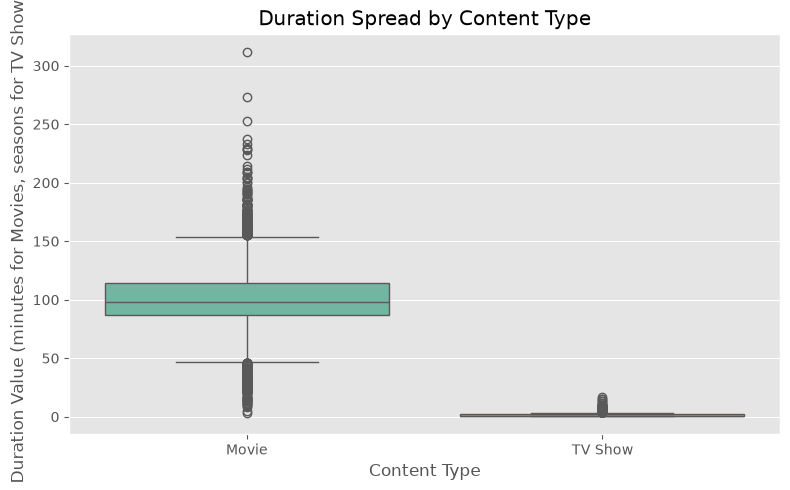

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="type", y="duration_value", data=df, palette="Set2")
plt.title("Duration Spread by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Duration Value (minutes for Movies, seasons for TV Shows)")
plt.tight_layout()
plt.show()

## INSIGHT

The chart shows that movies typically run between 87 and 114 minutes, while TV Shows mostly have just 1 to 2 seasons, with a few outliers running much longer.

## HEAT MAP

This heatmap shows how strongly numeric fields — release year, duration, year added, and month added — relate to one another using correlation values.

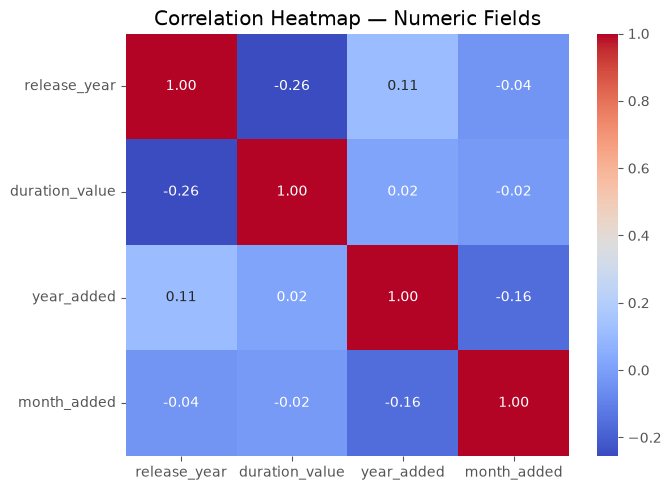

In [19]:
numeric_cols = df[["release_year", "duration_value", "year_added", "month_added"]]

plt.figure(figsize=(7, 5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap — Numeric Fields")
plt.tight_layout()
plt.show()

## INSIGHT

The chart shows only weak relationships overall, with release year and duration having the strongest link, meaning newer titles tend to have slightly shorter durations than older ones.

## CATEGORY COMPARISON CHART

This bar chart compares the number of titles produced by the top 10 countries, excluding entries where the country is unknown

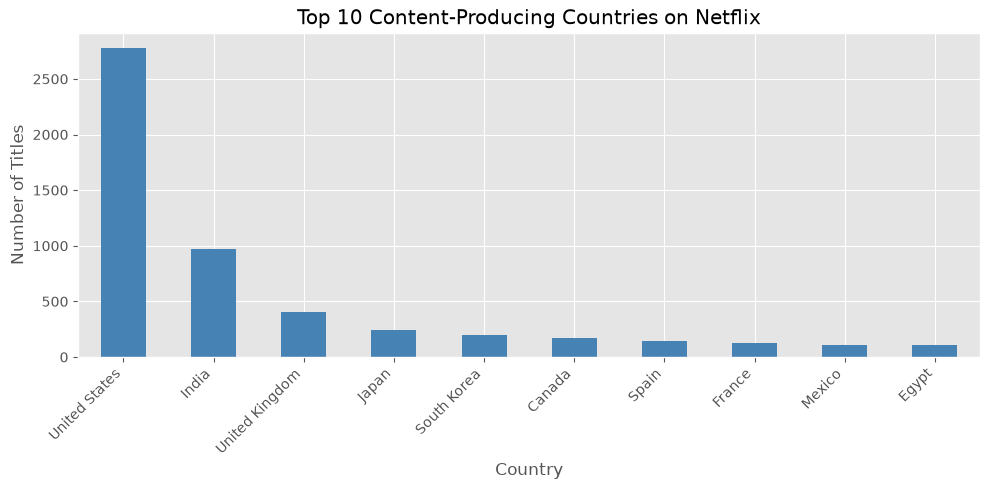

In [21]:
top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar", color="steelblue")
plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## INSIGHT 

The chart shows that the United States produces far more Netflix content than any other country, with India as a distant second, highlighting how concentrated content production is in just a few regions.